In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mode
from matplotlib.ticker import MaxNLocator
import numpy as np
import altair as alt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
df = pd.read_csv('NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-direction.csv')

In [111]:
df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr),Next_Day_Direction
0,06-Nov-2023,19345.85,19423.0,19309.70,19411.75,180690631,16296.56,down
1,07-Nov-2023,19404.05,19423.5,19329.10,19406.70,198660124,18288.06,up
2,08-Nov-2023,19449.60,19464.4,19401.50,19443.50,194967997,17060.45,down
3,09-Nov-2023,19457.40,19463.9,19378.35,19395.30,208418472,19087.29,up
4,10-Nov-2023,19351.85,19451.3,19329.45,19425.35,152215785,12916.21,up


In [112]:
 df.tail()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr),Next_Day_Direction
492,30-Oct-2025,25984.40,26032.05,25845.25,25877.85,257373001,24180.46,down
493,31-Oct-2025,25863.80,25953.75,25711.20,25722.10,334384400,28788.40,up
494,03-Nov-2025,25696.85,25803.10,25645.50,25763.35,275858501,23949.88,down
495,04-Nov-2025,25744.75,25787.40,25578.40,25597.65,305143084,29307.41,down
496,06-Nov-2025,25593.35,25679.15,25491.55,25509.70,371852417,36129.62,down


In [113]:
df.tail()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr),Next_Day_Direction
492,30-Oct-2025,25984.40,26032.05,25845.25,25877.85,257373001,24180.46,down
493,31-Oct-2025,25863.80,25953.75,25711.20,25722.10,334384400,28788.40,up
494,03-Nov-2025,25696.85,25803.10,25645.50,25763.35,275858501,23949.88,down
495,04-Nov-2025,25744.75,25787.40,25578.40,25597.65,305143084,29307.41,down
496,06-Nov-2025,25593.35,25679.15,25491.55,25509.70,371852417,36129.62,down


In [114]:
df.shape

(497, 8)

In [115]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded',
       'Turnover (₹ Cr)', 'Next_Day_Direction'],
      dtype='object')

#### Finding Missing Values

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                497 non-null    object 
 1   Open                497 non-null    float64
 2   High                497 non-null    float64
 3   Low                 497 non-null    float64
 4   Close               497 non-null    float64
 5   Shares Traded       497 non-null    int64  
 6   Turnover (₹ Cr)     497 non-null    float64
 7   Next_Day_Direction  497 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 31.2+ KB


##### -> NO missing values

In [117]:
df.describe()

,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
count,497.000000,497.000000,497.000000,497.000000,4.970000e+02,497.000000
mean,23614.514286,23718.071429,23494.897887,23608.341046,3.133477e+08,29898.873702
std,1517.582319,1519.314655,1516.385574,1512.436929,1.028521e+08,10003.745723
min,19345.850000,19423.000000,19309.700000,19395.300000,1.906457e+07,1572.770000
25%,22455.000000,22526.600000,22346.500000,22460.300000,2.507819e+08,23904.130000
50%,23992.950000,24189.550000,23870.300000,24008.000000,2.924338e+08,28235.170000
75%,24832.500000,24956.500000,24717.400000,24834.850000,3.587682e+08,33683.600000
max,26248.250000,26277.350000,26151.400000,26216.050000,1.006105e+09,93786.440000


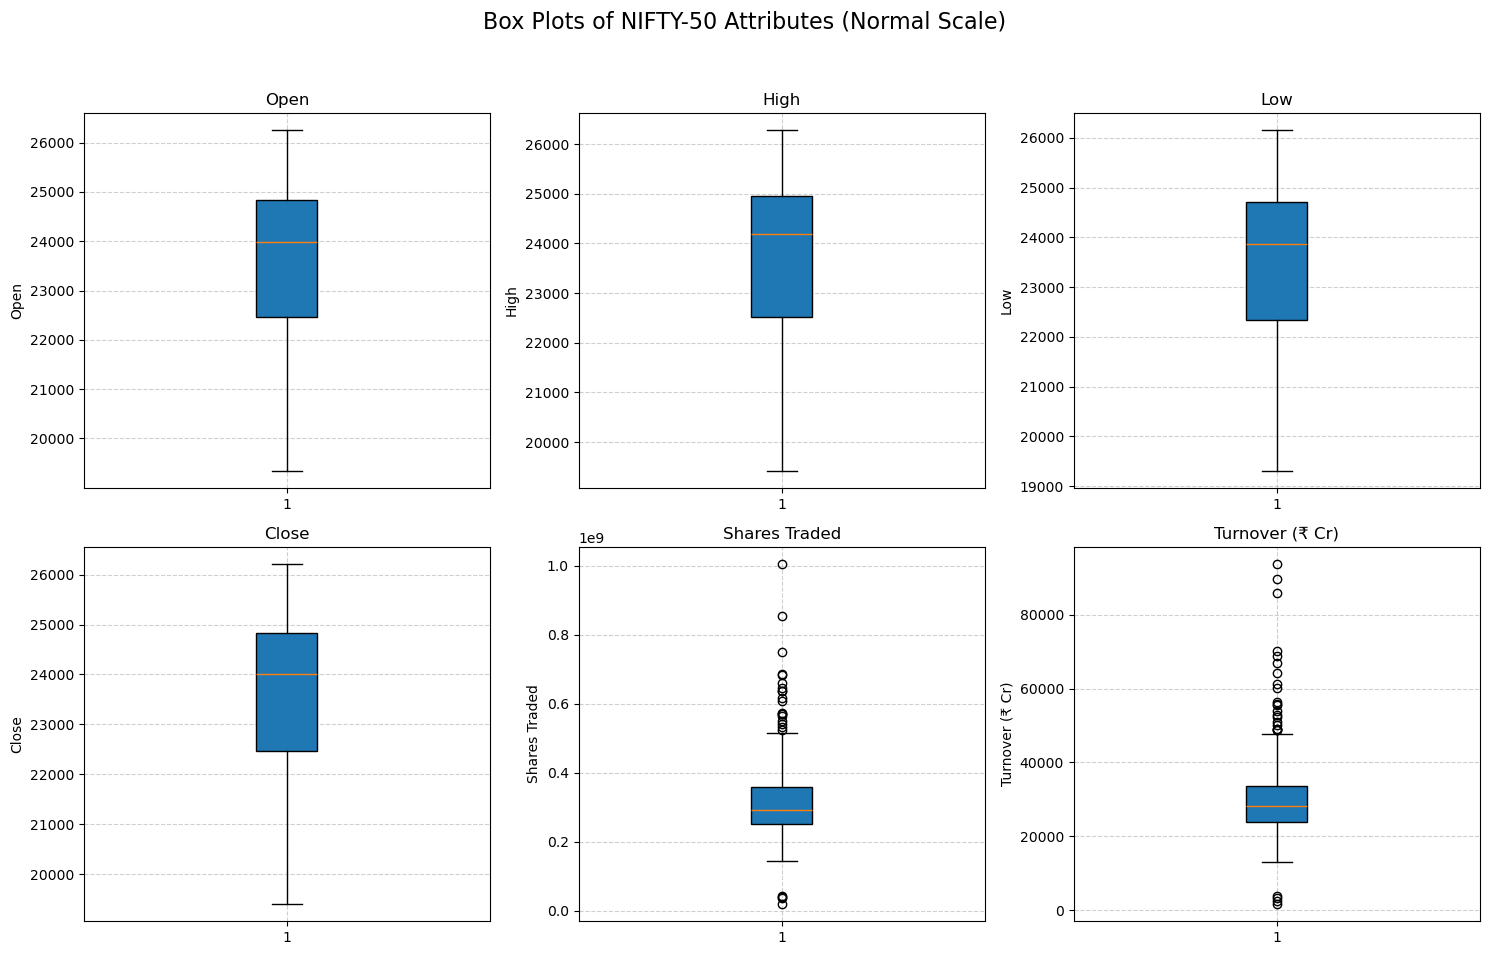

In [118]:
columns_to_plot = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle('Box Plots of NIFTY-50 Attributes (Normal Scale)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    ax.boxplot(df[col], vert=True, patch_artist=True)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [119]:
columns_to_check = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']
def analyze_outliers(df, columns):
    for col in columns:
        series = df[col]
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = series[(series < lower_bound) | (series > upper_bound)]

        print(f"--- Attribute: {col} ---")
        print(f"  Lower Bound (Q1 - 1.5*IQR): {lower_bound:.2f}")
        print(f"  Upper Bound (Q3 + 1.5*IQR): {upper_bound:.2f}")
        print(f"  Number of Outliers: {len(outliers)}")
        
        if len(outliers) > 0:
            print(f"  Outliers found (Min: {outliers.min():.2f}, Max: {outliers.max():.2f}):")
            if len(outliers) <= 20:
                print(f"    {outliers.to_list()}")
            else:
                print(f"    [First 10 values: {outliers.to_list()[:10]}... Total {len(outliers)} outliers]")
        else:
            print("  No Outliers Found.")
        print("-" * (25 + len(col)))

analyze_outliers(df, columns_to_check)

--- Attribute: Open ---
  Lower Bound (Q1 - 1.5*IQR): 18888.75
  Upper Bound (Q3 + 1.5*IQR): 28398.75
  Number of Outliers: 0
  No Outliers Found.
-----------------------------
--- Attribute: High ---
  Lower Bound (Q1 - 1.5*IQR): 18881.75
  Upper Bound (Q3 + 1.5*IQR): 28601.35
  Number of Outliers: 0
  No Outliers Found.
-----------------------------
--- Attribute: Low ---
  Lower Bound (Q1 - 1.5*IQR): 18790.15
  Upper Bound (Q3 + 1.5*IQR): 28273.75
  Number of Outliers: 0
  No Outliers Found.
----------------------------
--- Attribute: Close ---
  Lower Bound (Q1 - 1.5*IQR): 18898.47
  Upper Bound (Q3 + 1.5*IQR): 28396.67
  Number of Outliers: 0
  No Outliers Found.
------------------------------
--- Attribute: Shares Traded ---
  Lower Bound (Q1 - 1.5*IQR): 88802497.50
  Upper Bound (Q3 + 1.5*IQR): 520747565.50
  Number of Outliers: 23
  Outliers found (Min: 19064566.00, Max: 1006105058.00):
    [First 10 values: [37311902, 661460455, 19064566, 572122639, 569425569, 1006105058, 6384

In [120]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']

capping_flooring_values = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    floor = Q1 - 1.5 * IQR
    cap = Q3 + 1.5 * IQR
    capping_flooring_values[col] = {'floor': floor, 'cap': cap}

def cap_and_floor(series, floor, cap):
    return series.clip(lower=floor, upper=cap)

for col in numeric_cols:
    floor = capping_flooring_values[col]['floor']
    cap = capping_flooring_values[col]['cap']
    df[col] = cap_and_floor(df[col], floor, cap)

updated_file_path = 'NIFTY-50-Joint-06-11-2023-to-06-11-2025-treated.csv'
df.to_csv(updated_file_path, index=False)

##### Outlier data Treated data set - "NIFTY-50-Joint-06-11-2023-to-06-11-2025-treated"

In [121]:
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).fillna(0)
    loss = (-delta.where(delta < 0, 0)).fillna(0)
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_macd_hist(data, fast=12, slow=26, signal=9):
    exp1 = data.ewm(span=fast, adjust=False).mean()
    exp2 = data.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - signal_line
    return macd_hist

# Load data
file_path = 'NIFTY-50-Joint-06-11-2023-to-06-11-2025-treated.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], dayfirst=True)
df.sort_values('Date', inplace=True)

# Feature engineering
df['Lagged_Return_1D'] = df['Close'].pct_change(1)
df['Volatility_14D'] = df['Close'].rolling(window=14).std()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['RSI_14'] = compute_rsi(df['Close'], window=14)
df['MACD_Hist'] = compute_macd_hist(df['Close'], fast=12, slow=26, signal=9)

# Print the new features for the last 10 rows
print(df[['Lagged_Return_1D', 'Volatility_14D', 'SMA_50', 'RSI_14', 'MACD_Hist']].tail(10))

# Save new dataset with features
output_file = 'NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-features.csv'
df.to_csv(output_file, index=False)


     Lagged_Return_1D  Volatility_14D     SMA_50     RSI_14  MACD_Hist
487          0.000881      340.456954  25011.120  86.155849  86.011701
488         -0.003717      328.426129  25035.322  80.082142  73.670931
489          0.006625      339.715081  25064.895  79.914472  71.519516
490         -0.001150      338.642831  25091.232  77.892325  62.892967
491          0.004538      328.535575  25119.684  82.726594  59.933099
492         -0.006757      307.569194  25139.702  72.026202  41.797119
493         -0.006019      285.933977  25154.531  63.378772  16.299999
494          0.001604      249.888524  25168.787  66.589291   0.060589
495         -0.006432      187.314813  25179.065  63.303616 -22.732175
496         -0.003436      156.400449  25191.857  55.783750 -43.423985


##### Feature-Engineered FILE - NIFTY-50-Feature-Engineered.csv

#### Split the data into training and testing sets using a time-based split. 

In [122]:
file_path = 'NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-features.csv'
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')
split_date = data['Date'].iloc[int(len(data) * 0.8)]
train_data = data[data['Date'] <= split_date]
test_data = data[data['Date'] > split_date]
print("Training Data Head:")
print(train_data.head())

print("\nTesting Data Head:")
print(test_data.head())

Training Data Head:
        Date      Open     High       Low     Close  Shares Traded  \
0 2023-11-06  19345.85  19423.0  19309.70  19411.75    180690631.0   
1 2023-11-07  19404.05  19423.5  19329.10  19406.70    198660124.0   
2 2023-11-08  19449.60  19464.4  19401.50  19443.50    194967997.0   
3 2023-11-09  19457.40  19463.9  19378.35  19395.30    208418472.0   
4 2023-11-10  19351.85  19451.3  19329.45  19425.35    152215785.0   

   Turnover (₹ Cr) Next_Day_Direction  Lagged_Return_1D  Volatility_14D  \
0         16296.56               down               NaN             NaN   
1         18288.06                 up         -0.000260             NaN   
2         17060.45               down          0.001896             NaN   
3         19087.29                 up         -0.002479             NaN   
4         12916.21                 up          0.001549             NaN   

   SMA_50  RSI_14  MACD_Hist  
0     NaN     NaN   0.000000  
1     NaN     NaN  -0.322279  
2     NaN     N

#### Train at least two ML models, such as: 
##### (1) Logistic Regression 
##### (2) Random Forest 

In [123]:
import pandas as pd

file_path = 'NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-features.csv'
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()
print("Column names in CSV:", list(data.columns))

Column names in CSV: ['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)', 'Next_Day_Direction', 'Lagged_Return_1D', 'Volatility_14D', 'SMA_50', 'RSI_14', 'MACD_Hist']


In [124]:
df = pd.read_csv("NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-features.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

split_date = '2025-01-01'

# Separate the data chronologically
train_data = df.loc[df.index < split_date]
test_data = df.loc[df.index >= split_date]

print(f"Total data points: {len(df)}")
print(f"Training set size (before {split_date}): {len(train_data)}")
print(f"Testing set size (on or after {split_date}): {len(test_data)}")

Total data points: 497
Training set size (before 2025-01-01): 286
Testing set size (on or after 2025-01-01): 211


In [125]:
target_column = 'Next_Day_Direction'

features_to_exclude = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)', 'Next_Day_Direction']

# Select all columns EXCEPT the ones to exclude as features
X_train = train_data.drop(columns=features_to_exclude, errors='ignore')
y_train = train_data[target_column]

X_test = test_data.drop(columns=features_to_exclude, errors='ignore')
y_test = test_data[target_column]

print("\nShape after splitting X and y:")
print(f"X_train shape: {X_train.shape}")
print(f"y_test shape: {y_test.shape}")


Shape after splitting X and y:
X_train shape: (286, 5)
y_test shape: (211,)


In [126]:

# 1. Load the data
file_path = "NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-features.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 2. Handle missing values
# Dropping rows with NaNs (which mainly occur at the start due to rolling window features)
df.dropna(inplace=True)

# 3. Define the target and encode it
target_column = 'Next_Day_Direction'
# Encode 'up' as 1 and 'down' as 0
df['Target'] = df[target_column].apply(lambda x: 1 if x == 'up' else 0)

# 4. Define features (X) and target (y)
# Exclude original price/volume columns and the target columns
features_to_exclude = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)', 'Next_Day_Direction', 'Target']
X = df.drop(columns=features_to_exclude, errors='ignore')
y = df['Target']

# 5. Time-Based Split
# Choosing '2025-01-01' as the split date
split_date = '2025-01-01'

X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]

X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]

# --- Model Training and Evaluation ---

# 6. Logistic Regression Model
log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(X_train, y_train)

y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)

# 7. Random Forest Classifier Model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_train_pred_rf = rf_clf.predict(X_train)
y_test_pred_rf = rf_clf.predict(X_test)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Logistic Regression Training Accuracy: {train_accuracy_lr:.4f}")
print(f"Logistic Regression Testing Accuracy: {test_accuracy_lr:.4f}")
print(f"Random Forest Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Random Forest Testing Accuracy: {test_accuracy_rf:.4f}")

Logistic Regression Training Accuracy: 0.5443
Logistic Regression Testing Accuracy: 0.5024
Random Forest Training Accuracy: 1.0000
Random Forest Testing Accuracy: 0.4550


In [128]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [129]:
y_test_pred_lr = log_reg.predict(X_test)

print("--- Logistic Regression Metrics ---")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr, target_names=['down (0)', 'up (1)']))

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
print(cm_lr)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}\n")


# --- Random Forest Evaluation ---
y_test_pred_rf = rf_clf.predict(X_test)

print("--- Random Forest Classifier Metrics ---")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf, target_names=['down (0)', 'up (1)']))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
print(cm_rf)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")

--- Logistic Regression Metrics ---

Classification Report:
              precision    recall  f1-score   support

    down (0)       0.00      0.00      0.00       105
      up (1)       0.50      1.00      0.67       106

    accuracy                           0.50       211
   macro avg       0.25      0.50      0.33       211
weighted avg       0.25      0.50      0.34       211


Confusion Matrix:
[[  0 105]
 [  0 106]]
Accuracy: 0.5024

--- Random Forest Classifier Metrics ---

Classification Report:
              precision    recall  f1-score   support

    down (0)       0.46      0.50      0.48       105
      up (1)       0.45      0.41      0.43       106

    accuracy                           0.45       211
   macro avg       0.45      0.46      0.45       211
weighted avg       0.45      0.45      0.45       211


Confusion Matrix:
[[53 52]
 [63 43]]
Accuracy: 0.4550


C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Visualizations

                  count          mean           std           min  \
Open              497.0  2.361451e+04  1.517582e+03  1.934585e+04   
High              497.0  2.371807e+04  1.519315e+03  1.942300e+04   
Low               497.0  2.349490e+04  1.516386e+03  1.930970e+04   
Close             497.0  2.360834e+04  1.512437e+03  1.939530e+04   
Shares Traded     497.0  3.090956e+08  8.537866e+07  8.880250e+07   
Turnover (₹ Cr)   497.0  2.940898e+04  7.921390e+03  9.234925e+03   
Lagged_Return_1D  496.0  5.849199e-04  8.244557e-03 -5.929358e-02   
Volatility_14D    484.0  2.755773e+02  1.093111e+02  1.176446e+02   
SMA_50            448.0  2.369319e+04  1.201201e+03  2.076384e+04   
RSI_14            484.0  5.557583e+01  1.833927e+01  2.022397e+00   
MACD_Hist         497.0  1.664663e+00  5.713657e+01 -1.406333e+02   

                           25%           50%           75%           max  
Open              2.245500e+04  2.399295e+04  2.483250e+04  2.624825e+04  
High              2.2

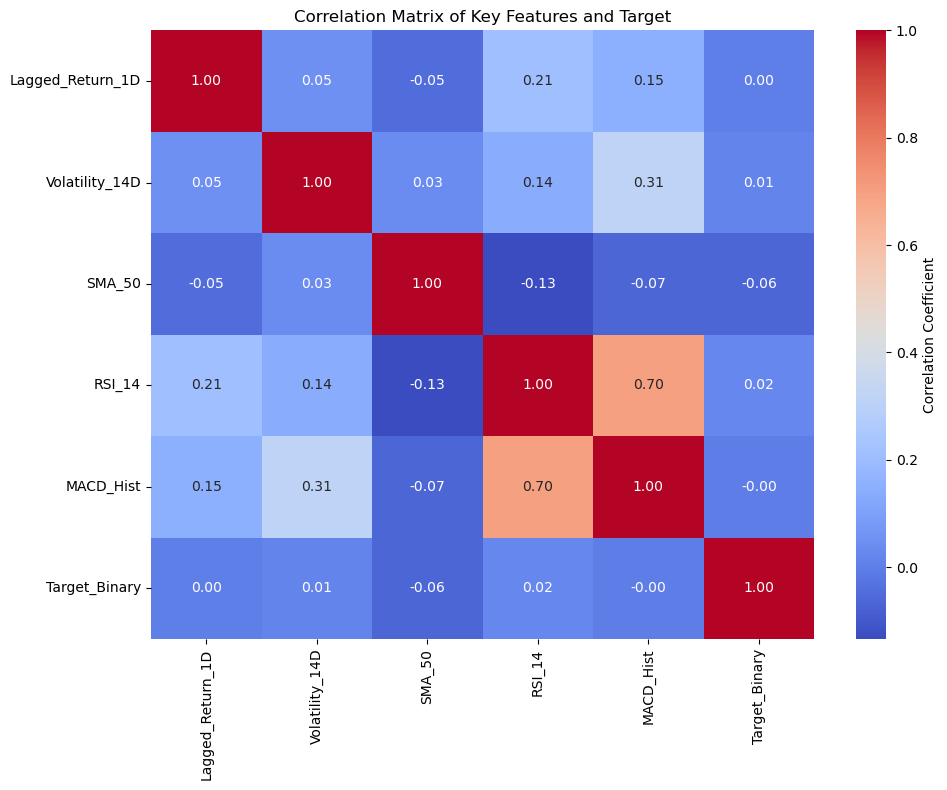

In [131]:
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the data
file_path = "NIFTY-50-Joint-06-11-2023-to-06-11-2025-with-features.csv"
df = pd.read_csv(file_path)

# 2. Initial Inspection & Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 3. Summary Statistics
print(df.describe().T)
print(df['Next_Day_Direction'].value_counts(normalize=True))

# 4. Visualization: Close Price Time Series
plt.figure(figsize=(12, 6))
df['Close'].plot(title='NIFTY-50 Close Price Over Time')
plt.ylabel('Close Price (₹)')
plt.grid(True)
plt.tight_layout()
plt.savefig('nifty_close_price_time_series.png')
plt.close()

# 5. Visualization: Lagged Return Distribution
plt.figure(figsize=(10, 6))
# Convert to percentage for better readability
sns.histplot(df['Lagged_Return_1D'].dropna() * 100, bins=50, kde=True)
plt.title('Distribution of 1-Day Lagged Returns (%)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('lagged_return_distribution.png')
plt.close()

# 6. Correlation Heatmap
correlation_features = ['Lagged_Return_1D', 'Volatility_14D', 'SMA_50', 'RSI_14', 'MACD_Hist']

# Create a temporary binary target column (1=up, 0=down) for correlation
corr_df = df[correlation_features].copy()
corr_df['Target_Binary'] = df['Next_Day_Direction'].apply(lambda x: 1 if x == 'up' else 0)

correlation_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Key Features and Target')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')